# Evaluation attempt inspection

Load a single already-completed evaluation attempt by job ID or file path and inspect:
the stored prompts, model response metrics, pass/fail card, and board plots.

Set `JOB_ID` to the job ID (filename without `.json`) or a full path to the attempt file.
Optionally set `CASE_SET` to narrow the search when multiple case sets are present.

The move plot is produced for one 2D plane per axis pair that includes the move axis.
A 4D move on axis 0 produces planes (0,1), (0,2), (0,3).  
Boards with more than 4 dimensions cannot be plotted.

In [1]:
import sys
from pathlib import Path
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "visualization":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from visualization.evaluation_figures import (
    display_attempt_prompt,
    display_attempt_response,
    display_attempt_summary,
    load_evaluation_attempt,
    plot_attempt_move,
)

In [2]:
JOB_ID = "2g_2b_all.low.r00.g01.b00__anthropic_claude-sonnet-4-6__medium__forbidden-snippets"
CASE_SET = None  # set to e.g. "2g_2b_all" to narrow the file search

In [3]:
context = load_evaluation_attempt(JOB_ID, case_set=CASE_SET)

## Prompt

In [4]:
display(display_attempt_prompt(context))


### Attempt
`2g_2b_all.low.r00.g01.b00__anthropic_claude-sonnet-4-6__medium__forbidden-snippets.json`

### System prompt
```text
You solve a multidimensional formal-language Scrabble benchmark.
Follow the supplied rules exactly and return one move in the required structured format.
Do not use tools or add explanations.
```

### User prompt (board configuration redacted)
```text
Place exactly one contiguous sequence. Maximize the number of newly placed rack symbols.

## Move geometry
- Coordinates are zero-based vectors with 2 entries.
- `start` is the first coordinate. `axis` advances one coordinate component per symbol.
- Axis selects the board dimension along which the sequence advances: axis 0 advances coordinate index 0, axis 1 advances coordinate index 1.

## Validity rules
- The submitted sequence must be accepted by the formal language.
- Existing cells may be reused only with their existing symbol.
- Reuse at least one existing cell and place at least one new symbol.
- Only newly placed symbols consume the rack, including multiplicities.
- Do not reuse a cell whose existing word already runs along the chosen axis.
- The cell immediately before and after the submitted sequence on its axis must not continue an existing word.
- A newly placed cell must not extend an already-valid word on any perpendicular axis.
- After placement, every maximal contiguous line of length greater than one that touches the move, on every axis, must be accepted by the formal language.

Formal language:
Language ID: 2g_2b_all.low.r00.g01
Alphabet: {C, M, V, Y}
k: 2
Minimum word length: 3
Forbidden snippets: {C V}
A sequence is valid iff it has the minimum length of 3 and contains no forbidden snippet.

Board configuration:
[omitted from notebook display: 55 occupied cells]

Rack:
["C", "M", "M", "M", "M", "Y", "Y"]

```

### Raw model response
```text
{"start":[-9,-3],"axis":0,"sequence":["Y","Y","C","M","M","M","M","M","M"]}
```


## Response metrics

In [5]:
display(display_attempt_response(context))

## Evaluation summary

In [6]:
display(display_attempt_summary(context))

parse,OK
sequence,OK
spatial,OK
overlap,OK
no word extension,OK
cross words,OK
rack,OK


## Board visualization — parsed move

Blue = newly placed tile, green = reused tile that matches, red = symbol conflict.

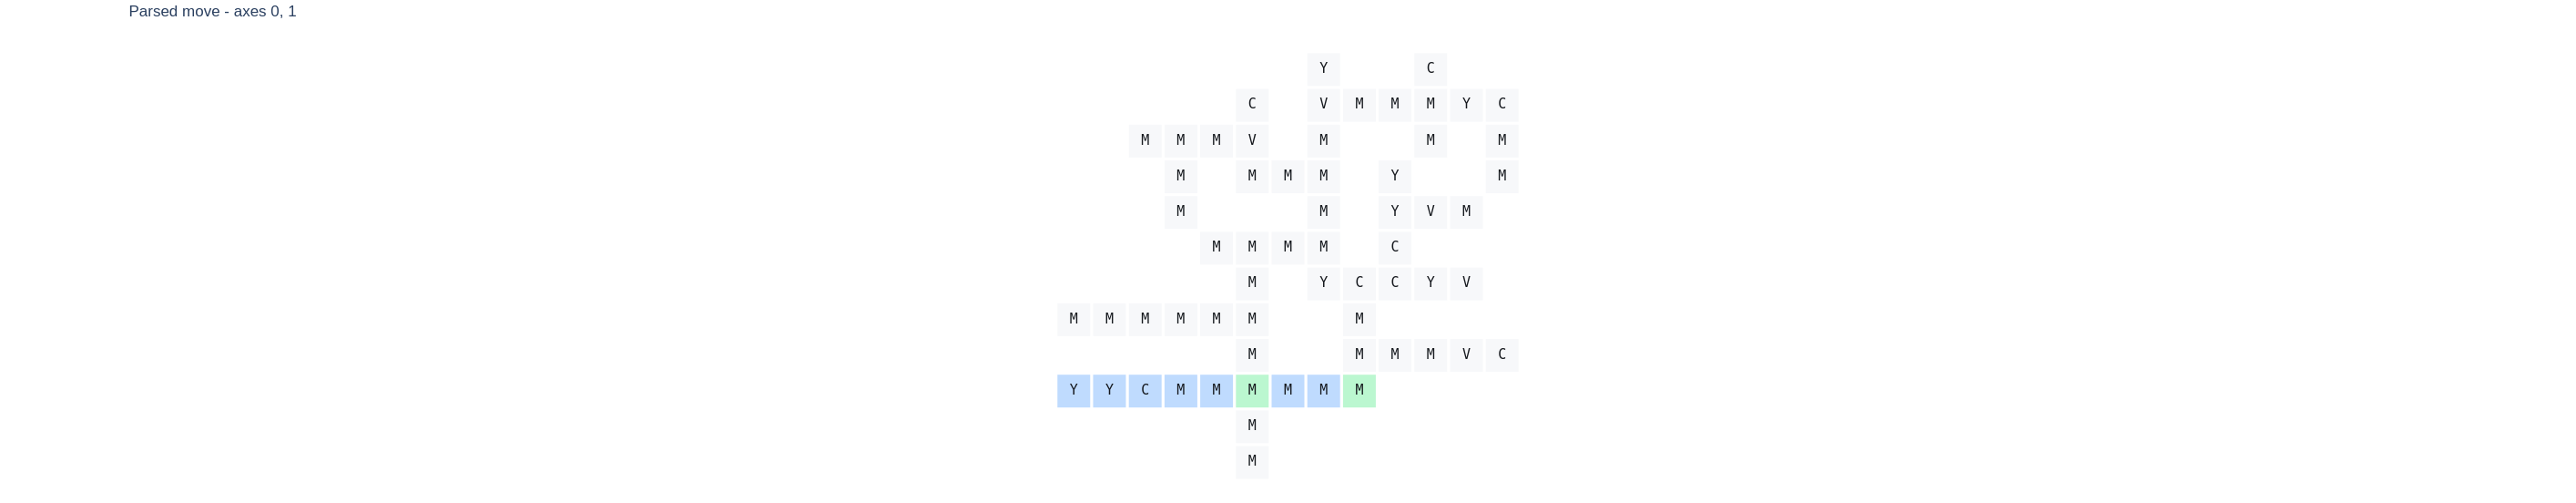

In [7]:
for figure in plot_attempt_move(context, move_source="parsed"):
    display(figure)

## Board visualization — ground truth

Ground truth ≠ only valid solution; it is the move the generator witness-chain selected.

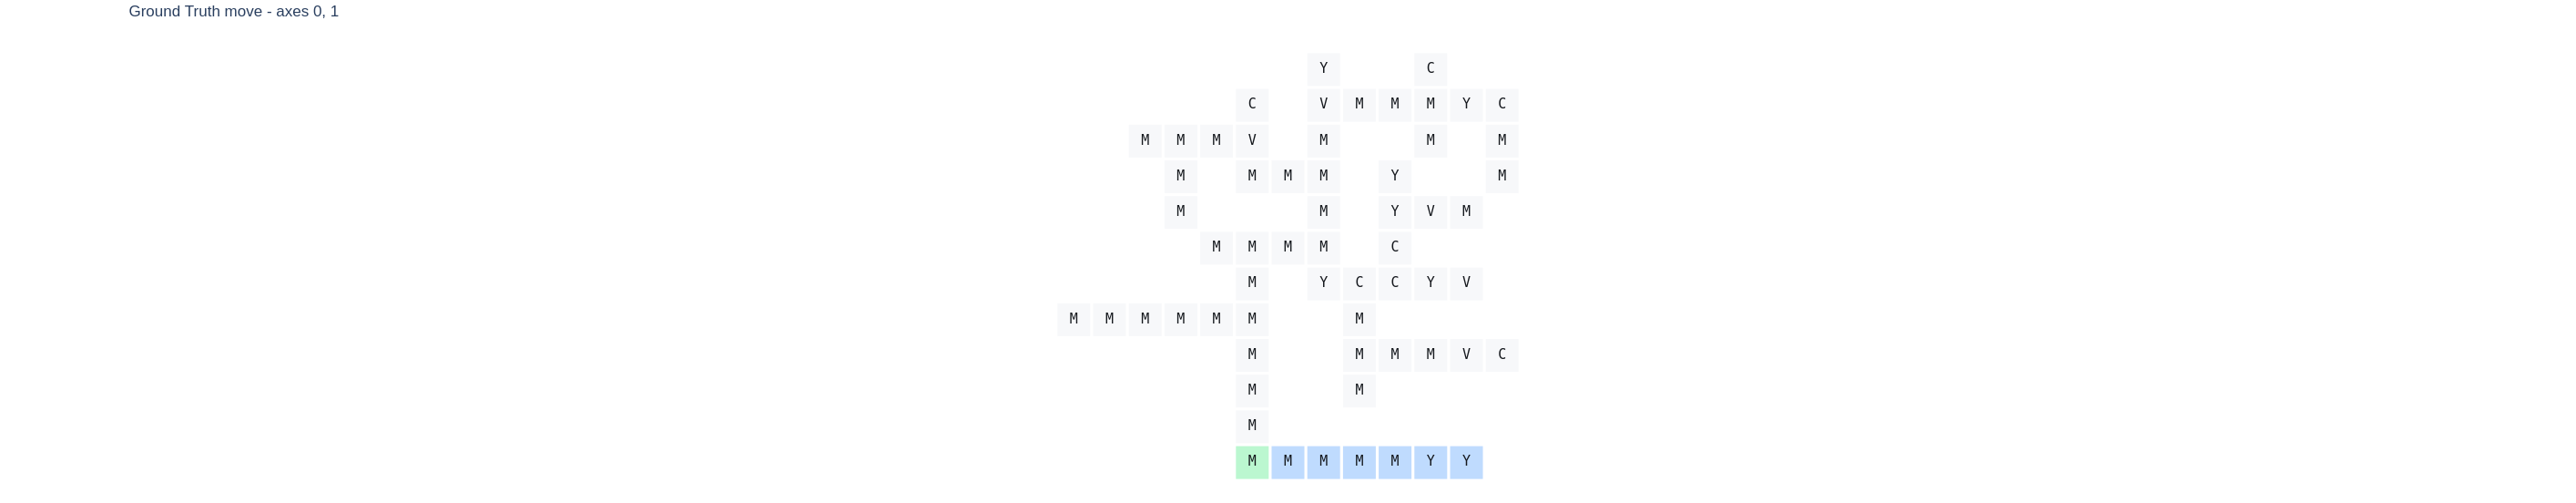

In [8]:
for figure in plot_attempt_move(context, move_source="ground_truth"):
    display(figure)